## Problem: Add Grad-CAM to Explain Model Predictions

### Problem Statement
Use Grad-CAM (Gradient-weighted Class Activation Mapping) to explain the predictions of a convolutional neural network (e.g., ResNet). Grad-CAM highlights the regions in the input image that contribute most to the model's predictions.

### Requirements

1. Forward Pass: Perform a forward pass with the input image to get the model's output.
    ```
    output = ...
    ```

2. Backward Pass: Backpropagate the gradients for the predicted class (use the class with the highest output probability).
    ```
    predicted_class = ...
    model.zero_grad()
    ...
    ```
3. Generate Grad-CAM Heatmap: Backpropagate the gradients for the predicted class (use the class with the highest output probability).
    ```
    predicted_class = ...
    model.zero_grad()
    ...
    ```
4. Generate Grad-CAM Heatmap:
    ```
    weights = ...
    heatmap = ...
    ```

In [2]:
# Explain a CNN model's predictions using Grad-CAM in PyTorch
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
# Load a pre-trained ResNet model
model = models.resnet18(pretrained=True)
model.eval()

# Define variables to capture gradients and activations
gradients = None
activations = None

# Define hooks to capture gradients and activations
def save_gradients(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]

def save_activations(module, input, output):
    global activations
    activations = output

# Attach hooks to the target layer
target_layer = model.layer4[1].conv2
target_layer.register_backward_hook(save_gradients)
target_layer.register_forward_hook(save_activations)

/Users/zireael/TorchLeet/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/zireael/TorchLeet/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
# Fetch a sample image from torchvision datasets
dataset = datasets.FakeData(transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
]))
image, _ = dataset[0]  # Get the first image
image = transforms.ToPILImage()(image)  # Convert to PIL for visualization

# Preprocess the image for the model
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
input_tensor = preprocess(image).unsqueeze(0)

# TODO: Perform a forward pass
output = model(input_tensor)
prob = torch.amax(output)

# TODO: Perform a backward pass for the predicted class
model.zero_grad()
prob.backward()

/Users/zireael/TorchLeet/.venv/lib/python3.13/site-packages/torch/nn/modules/module.py:1869: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [11]:
# Generate Grad-CAM heatmap
weights: torch.Tensor = gradients.mean((2, 3), keepdim=True)
heatmap: torch.Tensor = (weights * activations).squeeze(0).sum(dim=0).relu()
print(f'heatmap = {heatmap.shape}')

# Normalize the heatmap and overlay it on the original image
heatmap = heatmap / heatmap.max()
heatmap = transforms.ToPILImage()(heatmap.cpu())
heatmap = heatmap.resize(image.size, resample=Image.BILINEAR)

heatmap = torch.Size([7, 7])


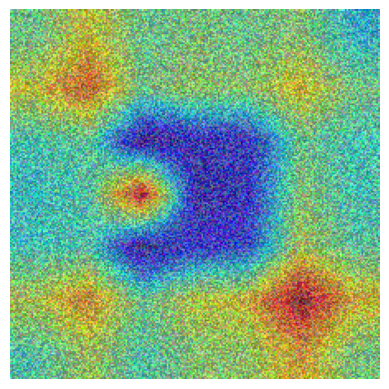

In [10]:
# Display the image with the Grad-CAM heatmap
plt.imshow(image)
plt.imshow(heatmap, alpha=0.5, cmap='jet')
# plt.title(f"Predicted Class: {predicted_class}")
plt.axis('off')
plt.show()
